In [4]:
import numpy as np
import pandas as pd

In [5]:
poplabels = 'data/SGDP_sub_aDNA.poplabels'
metadata = 'data/SGDP_metadata.279public.21signedLetter.samples.txt'
ancients_metadata = 'data/ancient_samples_locations_sheet1.csv'

In [6]:
IDs = []
with open(poplabels, "r") as f:
    next(f) #Skip header
    for line in f:
        l = line.strip().split(' ') #Split words by spaces
        IDs.append(l[0]) #ID is the first word, add it
IDs = [s[:-3] if s.endswith('.DG') else s for s in IDs] #Remove the trailing .DG (signifying high coverage contemporary samples)



['B_Australian-3', 'B_Australian-4', 'B_Crete-1', 'B_Crete-2', 'B_Dai-4', 'B_Dinka-3', 'B_French-3', 'B_Han-3', 'B_Ju_hoan_North-4', 'B_Karitiana-3', 'B_Mandenka-3', 'B_Mbuti-4', 'B_Mixe-1', 'B_Papuan-15', 'B_Sardinian-3', 'B_Yoruba-3', 'S_Abkhasian-1', 'S_Abkhasian-2', 'S_Adygei-1', 'S_Adygei-2', 'S_Albanian-1', 'S_Aleut-1', 'S_Aleut-2', 'S_Altaian-1', 'S_Ami-1', 'S_Ami-2', 'S_Armenian-1', 'S_Armenian-2', 'S_Atayal-1', 'S_Balochi-1', 'S_Balochi-2', 'S_BantuHerero-1', 'S_BantuHerero-2', 'S_BantuKenya-1', 'S_BantuKenya-2', 'S_BantuTswana-1', 'S_BantuTswana-2', 'S_Basque-1', 'S_Basque-2', 'S_BedouinB-1', 'S_BedouinB-2', 'S_Bengali-1', 'S_Bengali-2', 'S_Bergamo-1', 'S_Bergamo-2', 'S_Biaka-1', 'S_Biaka-2', 'S_Bougainville-1', 'S_Bougainville-2', 'S_Brahmin-1', 'S_Brahmin-2', 'S_Brahui-1', 'S_Brahui-2', 'S_Bulgarian-1', 'S_Bulgarian-2', 'S_Burmese-1', 'S_Burmese-2', 'S_Burusho-1', 'S_Burusho-2', 'S_Cambodian-1', 'S_Cambodian-2', 'S_Chane-1', 'S_Chechen-1', 'S_Chukchi-1', 'S_Czech-2', 'S_Dai

In [7]:
accessions_contemporary = [] #Column 4
lat_contemporary = [] #Column 11
lon_contemporary= [] #Column 12
with open(metadata,"rb") as f:
    next(f)
    for line in f:
        l = line.strip().split(b'\t')
        if l != [b'']:
            accessions_contemporary.append(l[4])
            lat_contemporary.append(l[11])
            lon_contemporary.append(l[12])

In [8]:
accessions_contemporary = [
    x.decode('utf-8') if isinstance(x, bytes) else x
    for x in accessions_contemporary
]
lat_contemporary = [
    x.decode('utf-8') if isinstance(x, bytes) else x
    for x in lat_contemporary
]

lon_contemporary = [
    x.decode('utf-8') if isinstance(x, bytes) else x
    for x in lon_contemporary
]

#Decode byte strings to utf-8 format
#print(lat_contemporary)

In [9]:
accessions_ancient = []
lat_ancient = []
lon_ancient = []
with open(ancients_metadata) as f:
    next(f)
    next(f)
    next(f) #Skip first 3 lines
    for line in f:
        l = line.split(',')
        if (l[0] != '' and l[17] != '' and l[18] != ''): #Skip empty lines
            accessions_ancient.append(l[0]) #ID
            lat_ancient.append(l[17]) # lat
            lon_ancient.append(l[18]) #lon

In [7]:
print(len(accessions_contemporary))

301


In [8]:
for ID in IDs:
    if (ID not in accessions_ancient and ID not in accessions_contemporary):
        print(ID + " not found")

2HxC5x196x1131 not found
C10427 not found
Dil16 not found
KH150189_KH150632_KH150636 not found
KH150204_KH150634 not found
KH150610 not found
KH150612 not found
KH150613_KH180043 not found
KH150614_KH150615 not found
KH150619 not found
KH150622 not found
KH150627 not found
KH150629 not found
KH150630 not found
KH150633 not found
KH150635 not found
KH150637 not found
KH150640 not found
KH150641 not found
PCA0011 not found
PCA0059_relative_of_PCA0031 not found
PCA0103 not found
PCA0124 not found
PCA0143 not found
PCA0148 not found
PCA0157 not found
PCA0167 not found
PCA0194 not found
PCA0340 not found
PCA0344 not found
PCA0354 not found
prs009 not found
prs013 not found
ROUQE not found
ROUQF not found
ROUQH not found


In [10]:
with open("data/aDNA_updated.poplabels", "w") as f_pop, \
     open("data/SGDP_aDNA_new.locations", "w") as f_loc, \
     open(poplabels, "r") as f_orig_pop:

    next(f_orig_pop)  # Skip header line
    for ID, line in zip(IDs, f_orig_pop):
        if ID in accessions_ancient:
            idx = accessions_ancient.index(ID)
            lat, lon = lat_ancient[idx], lon_ancient[idx]
        elif ID in accessions_contemporary:
            idx = accessions_contemporary.index(ID)
            lat, lon = lat_contemporary[idx], lon_contemporary[idx]
        else:
            continue  # Skip if ID is not in either list

        # Skip entries with "NA" lat/lon
        if lat == "NA" or lon == "NA" or lat == ".." or lon == "..":
            continue

        f_pop.write(line)
        f_loc.write(f"{lat} {lon}\n")
        f_loc.write(f"{lat} {lon}\n") #Write location twice

In [13]:
contemporary_IDs = IDs[:278]
for ID in IDs:
    if (ID in accessions_contemporary):
        #print(ID)
        if (ID not in contemporary_IDs):
            print("wrong")
# There are 278 contemporary samples. Save them into a new poplabels file then use that poplabels to run extract_subtrees rule to get new anc mut files
# and then use those anc mut files to run the rest of the pipeline

In [26]:
with open("data/SGDP_contemporary_only.poplabels", "w") as f_pop, \
     open("data/SGDP_contemporary_only.locations", "w") as f_loc, \
     open(poplabels, "r") as f_orig_pop:

    header = next(f_orig_pop)  # Store header line
    f_pop.write(header)
         
    for ID, line in zip(contemporary_IDs, f_orig_pop):
        if ID in accessions_contemporary:
            idx = accessions_contemporary.index(ID)
            lat, lon = lat_contemporary[idx], lon_contemporary[idx]
        else:
            print(f'Not found {line}')
            continue  # Skip if ID is not in either list

        # Skip entries with "NA" lat/lon
        if lat == "NA" or lon == "NA" or lat == ".." or lon == "..":
            print(f'Not found {line}')
            continue

        f_pop.write(line)
        f_loc.write(f"{lat} {lon}\n")
        f_loc.write(f"{lat} {lon}\n") #Write location twice

In [9]:
#Sanity check
with open("data/SGDP_aDNA_new_filtered.locations", "r") as f_full, \
     open("data/SGDP_contemporary_only.locations", "r") as f_sub:

    full_lines = [line.strip() for line in f_full.readlines()[:556]]
    sub_lines = [line.strip() for line in f_sub.readlines()]

    if full_lines == sub_lines:
        print("Match: First 556 lines of SGDP_aDNA_new_filtered.locations match SGDP_contemporary_only.locations exactly.")
    else:
        print("Mismatch: The two files differ.")


Match: First 556 lines of SGDP_aDNA_new_filtered.locations match SGDP_contemporary_only.locations exactly.


In [10]:
#Build a list of all the populations to pass to extract subtrees rule

input_file = "data/SGDP_contemporary_only.poplabels"
output_file = "data/contemporary_populations.txt"

populations = set()

with open(input_file, "r") as f_in:
    next(f_in)  # Skip header
    for line in f_in:
        parts = line.strip().split()
        if len(parts) >= 2:
            populations.add(parts[1])  # Second column is population name

with open(output_file, "w") as f_out:
    for pop in sorted(populations):
        f_out.write(f"{pop}\n")

print(f"Written {len(populations)} unique population names to {output_file}")


Written 130 unique population names to data/contemporary_populations.txt


In [35]:
#Create new poplabels and locations file for samples within our western european range
# Change these coordinates as needed
min_lon, max_lon = -30, 30
min_lat, max_lat = 35, 75

with open(poplabels, "r") as f_orig_pop, \
     open('data/contemporary_nw_samples_only.locations', "w") as f_loc, \
     open ('data/contemporary_nw_samples_only.poplabels', "w") as f_pop:

    next(f_orig_pop)  # Skip header line
    f_pop.write(header) #Write header in new poplabels
    num_contemporaries = 0
    num_samples_in_range = 0
    for ID, line in zip(IDs, f_orig_pop):
        if ID in accessions_contemporary:
            num_contemporaries += 1
            idx = accessions_contemporary.index(ID)
            lat, lon = lat_contemporary[idx], lon_contemporary[idx]
            lat = float(lat)
            lon = float(lon)
            
            if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
                f_pop.write(line)
                f_loc.write(f"{lat} {lon}\n")
                f_loc.write(f"{lat} {lon}\n") #Write location twice


            
#print(f' There are {num_contemporaries} contemporary samples\nThere are {num_samples_in_range} that are within the defined boundaries')

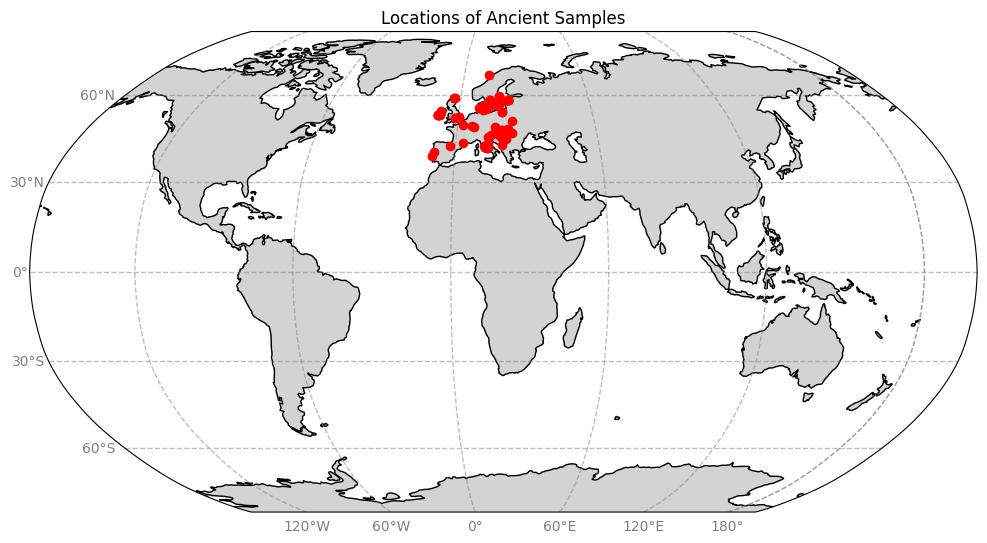

In [39]:
#Plot the samples to check that our code above worked
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import re
import seaborn as sns
from math import radians, sin, cos, asin, sqrt
import imageio
import os
from IPython.display import Image, display
import time
from scipy.stats import gaussian_kde
from statistics import mean
import statistics
import random
#Code to test if locations matches up with poplabels. It does.
fig = plt.figure(figsize=(10, 6), dpi=100)
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree()  # lat/lon
ax = plt.axes(projection=projection)
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

sample_locs = np.loadtxt("data/ancients_nw_samples_only_test.locations")
for sample in range (0, 100):
    sample = sample * 2 #Diploid
    location = sample_locs[sample]
    lon, lat = location[1], location[0]
    ax.plot([lon], [lat], marker='o', color='red', markersize=6, transform=data_crs)
    

# # Plot the point
# ax.plot([lon], [lat], marker='o', color='red', markersize=6, transform=data_crs)
# ax.text(lon, lat, str(sample), transform=data_crs, fontsize=8,
#         ha='left', va='bottom', color='black', weight='bold')

# Show immediately
plt.title(f"Locations of Ancient Samples")
plt.tight_layout()
plt.show()

In [14]:
#This chunk thins out the ancients. 
# It generates a "test" set (the samples we want to forget locations of)
# It then creates new files including only 10 ancients and 100 ancients along with the test set
import random

# Define spatial boundaries
min_lon, max_lon = -30, 30
min_lat, max_lat = 35, 75

# Filter ancient samples that fall within the lat/lon range
valid_ancients = []
for idx, ID in enumerate(accessions_ancient):
    lat, lon = lat_ancient[idx], lon_ancient[idx]
    if lat in ["NA", ".."] or lon in ["NA", ".."]:
        continue
    lat = float(lat)
    lon = float(lon)
    if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
        valid_ancients.append((ID, lat, lon))

# Shuffle and sample ancient IDs
random.seed(75)  # Ensure this doesnt keep changing
random.shuffle(valid_ancients)
ancients_10 = valid_ancients[:10]
ancients_100 = valid_ancients[:100]
ancients_test = [x for x in valid_ancients[100:] if x[0] not in [id for id, _, _ in ancients_10 + ancients_100]][:100]
ancients_test_IDs = [i[0] for i in ancients_test]
# print(ancients_test)
# print(ancients_test_IDs)

valid_contemporaries = []
for idx, ID in enumerate(accessions_contemporary):
    lat, lon = lat_contemporary[idx], lon_contemporary[idx]
    if lat in ["NA", ".."] or lon in ["NA", ".."]:
        continue
    lat = float(lat)
    lon = float(lon)
    if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
        valid_contemporaries.append((ID, lat, lon))
        
#Create new poplabels and locations file for samples within our western european range
min_lon, max_lon = -30, 30
min_lat, max_lat = 35, 75

with open(poplabels, "r") as f_orig_pop, \
     open('data/contemporary_nw_samples_only.locations', "w") as f_loc, \
     open ('data/contemporary_nw_samples_only.poplabels', "w") as f_pop:

    header = next(f_orig_pop)  # Skip header line
    f_pop.write(header) #Write header in new poplabels
    num_contemporaries = 0
    num_samples_in_range = 0
    for ID, line in zip(IDs, f_orig_pop):
        if ID in accessions_contemporary:
            num_contemporaries += 1
            idx = accessions_contemporary.index(ID)
            lat, lon = lat_contemporary[idx], lon_contemporary[idx]
            lat = float(lat)
            lon = float(lon)
            
            if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
                f_pop.write(line)
                f_loc.write(f"{lat} {lon}\n")
                f_loc.write(f"{lat} {lon}\n") #Write location twice
        elif ID in ancients_test_IDs:
            idx = ancients_test_IDs.index(ID)
            f_pop.write(line)
            f_loc.write(f"{ancients_test[idx][1]} {ancients_test[idx][2]}\n")
            f_loc.write(f"{ancients_test[idx][1]} {ancients_test[idx][2]}\n")
        

# Function to write data for a set
def write_ancient_subset(filename_prefix, ancient_subset, contemporaries):
    with open(poplabels, "r") as f_orig_pop, \
         open(f"data/{filename_prefix}.locations", "w") as f_loc, \
         open(f"data/{filename_prefix}.poplabels", "w") as f_pop:

        header = next(f_orig_pop)
        f_pop.write(header)

        for ID, line in zip(IDs, f_orig_pop):
            for cid, lat, lon in contemporaries:
                if ID == cid:
                    f_pop.write(line)
                    f_loc.write(f"{lat} {lon}\n")
                    f_loc.write(f"{lat} {lon}\n")
                    break
            for anc_id, lat, lon in ancient_subset:
                if ID == anc_id:
                    f_pop.write(line)
                    f_loc.write(f"{lat} {lon}\n")
                    f_loc.write(f"{lat} {lon}\n")
                    break

# Write each subset
write_ancient_subset("ancients_nw_samples_only_10", ancients_10 + ancients_test, valid_contemporaries)
write_ancient_subset("ancients_nw_samples_only_100", ancients_100 + ancients_test, valid_contemporaries)


In [12]:
# Set of test sample IDs
expected_test_ids = set(ancients_test_IDs)

# Function to extract IDs from a poplabels file
def extract_ids_from_poplabels(filepath):
    with open(filepath, "r") as f:
        next(f)  # Skip header
        return set(line.strip().split()[0] for line in f)

# Read sample IDs from all three files
ids_10 = extract_ids_from_poplabels("data/ancients_nw_samples_only_10.poplabels")
ids_100 = extract_ids_from_poplabels("data/ancients_nw_samples_only_100.poplabels")
ids_contemp = extract_ids_from_poplabels("data/contemporary_nw_samples_only.poplabels")

# Check that all test samples are in all files
assert expected_test_ids <= ids_10, "Some test IDs missing from ancients_nw_samples_only_10.poplabels"
assert expected_test_ids <= ids_100, "Some test IDs missing from ancients_nw_samples_only_100.poplabels"
assert expected_test_ids <= ids_contemp, "Some test IDs missing from contemporary_nw_samples_only.poplabels"

# Check that the sets of test IDs are the same across all files
test_ids_in_10 = ids_10 & expected_test_ids
test_ids_in_100 = ids_100 & expected_test_ids
test_ids_in_contemp = ids_contemp & expected_test_ids

assert test_ids_in_10 == expected_test_ids, "Mismatch in test IDs in ancients_nw_samples_only_10.poplabels"
assert test_ids_in_100 == expected_test_ids, "Mismatch in test IDs in ancients_nw_samples_only_100.poplabels"
assert test_ids_in_contemp == expected_test_ids, "Mismatch in test IDs in contemporary_nw_samples_only.poplabels"

print("✅ All 100 test samples are present and consistent across all files.")


✅ All 100 test samples are present and consistent across all files.
